In [2]:
#1. 导入库
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# 2. 读取数据，查看数据信息

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

import pandas as pd

data = pd.read_csv("E:/project/1/PJME_hourly.csv")
## 这一段代码的作用是读取CSV文件，并把它保存为一个Pandas DataFrame 类型的数据表, 变量名叫data。

print(data.head())
#print(data.head(10))
## data.head()的作用是查看变量data的前5行数据，head(10)是查看变量data的前10行数据；
## print（）是把结果输入到屏幕上。

#print(data.tail())
#print(data.tail(10))
## data.tail()是查看变量data的后5行数据，tail(10)是查看变量data的后10行数据。


print(data.shape)
## data.shape是查看数据有多少行，多少列：例如（100，2）意味着100行，2列。

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
(145366, 2)


In [4]:
# 3. 构造时间特征

data["Datetime"] = pd.to_datetime(data["Datetime"])
## 这段代码的作用：把data数据表中"Datetime"这一列:[str]   转换成真正的日期时间格式:datatime64[us].

data_index = data.set_index("Datetime").sort_index()
## 作用：把 data 数据表中的 ”time” 这一列设置为索引 index
## data = data.set_index("Datetime", drop=False)  drop=False:让 "time" 既作为索引，又保留在表格中。
## data = data.set_index["time"].sort_index()     .sort_index()按时间先后顺序排序。

data_index["hour"] = data_index.index.hour
## 这一段代码的作用是：从 data_index 的时间索引中提取 小时 的信息，并新增一列 hour 并保存这个结果。

data_index["dayofweek"] = data_index.index.dayofweek
## 从 data_index 的时间索引中提取“星期几”，并新增一列 "dayofweek" 保存结果。

data_index["month"] = data_index.index.month
## 从 data_index 的时间索引中提取“月份”，并新增一列 "month" 保存结果。

data_index["quarter"] = data_index.index.quarter
## 从 data_index 的时间索引中提取“季度”，并新增一列 "quarter" 保存结果。


data_index["year"]= data_index.index.year
## 从 data 数据表中的 Datetime 时间列中提取 年份， 然后新增一列 year 保存年份结果

data_index["dayofyear"]= data_index.index.dayofyear
## 从 data 数据表中的 Datetime 时间列中提取 “一年中的第几天”， 然后新增一列 dayofyear 保存年份结果

data_index["is_weekend"] = data_index["dayofweek"].apply(lambda x: 1 if x >= 5 else 0)
## 根据 dayofweek 这一列判断是否为周末，并增加一列 is_weekend
## .apply()  把一个函数引用到每一个数据上
## lambda x: 意味着临时定义一个小函数， 其中 x 表示当前正在处理的那个值

In [5]:
# 4. 加入历史负荷特征
data_index["lag_1"] = data_index["PJME_MW"].shift(1)
## 作用是：用上一时刻的 PJME_MW 值，生成一个新特征列 “lag_1”，在电力负荷预测中，这叫做滞后特征。
## .shift(1) 把这一列 整体向下移动1行

data_index["lag_24"] = data_index["PJME_MW"].shift(24)
data_index["lag_168"] = data_index["PJME_MW"].shift(168)
## 把过去的负荷值变成当前时刻的输入特征，让模型利用历史信息预测未来负荷.


In [6]:
# 5. 加入滑动平滑特征

data_index["rolling_mean_24"] = data_index["PJME_MW"].shift(1).rolling(window=24).mean()
## 作用是：计算 “PJME_MW” 这一列最近24个时间点的平均值，并生成一个新列 “rolling_mean_24”.
## .rolling(window=24) 设置滑动窗口大小为 24。
## .mean() 对窗口中的数计算平均值。
## .shift(1) 只使用当前时刻之前的数据来计算近 24 小时平均值。

data_index["rolling_mean_168"] = data_index["PJME_MW"].shift(1).rolling(window=168).mean()

data_index = data_index.dropna()
print(data_index.isna().sum())
print(data_index.shape)

data_index.head(250)

PJME_MW             0
hour                0
dayofweek           0
month               0
quarter             0
year                0
dayofyear           0
is_weekend          0
lag_1               0
lag_24              0
lag_168             0
rolling_mean_24     0
rolling_mean_168    0
dtype: int64
(145198, 13)


,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
Datetime,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,0,31187.0,26862.0,30393.0,33452.583333,32519.511905
2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,0,29445.0,25976.0,29265.0,33560.208333,32513.869048
2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,0,28670.0,25641.0,28357.0,33672.458333,32510.327381
2002-01-08 04:00:00,28542.0,4,1,1,1,2002,8,0,28375.0,25666.0,27899.0,33786.375000,32510.434524
2002-01-08 05:00:00,29261.0,5,1,1,1,2002,8,0,28542.0,26328.0,28057.0,33906.208333,32514.261905
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002-01-18 06:00:00,28479.0,6,4,1,1,2002,18,0,26353.0,28123.0,26612.0,31884.875000,30657.333333
2002-01-18 07:00:00,32477.0,7,4,1,1,2002,18,0,28479.0,32359.0,30639.0,31899.708333,30668.446429
2002-01-18 08:00:00,35145.0,8,4,1,1,2002,18,0,32477.0,34860.0,33601.0,31904.625000,30679.386905


In [7]:
# 6. 按时间顺序划分训练集和测试集

feature = [
    "hour",
    "dayofweek",
    "month",
    "quarter",
    "year",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

x = data_index[feature]
y = data_index["PJME_MW"]

train_ratio = 0.7
val_ratio = 0.85
train_index = int(len(data_index)*train_ratio)
val_index = int(len(data_index)*val_ratio)
## 作用是：计算一个数据划分的位置，用于把数据按 70%、15%和15% 分成训练集、测试集和验证集

x_train = x.iloc[:train_index]
x_val = x.iloc[train_index:val_index]
x_test = x.iloc[val_index:]

y_train = y.iloc[:train_index]
y_val = y.iloc[train_index:val_index]
y_test = y.iloc[val_index:]
## 按照 split_index 这个分割点， 把特征 x 和 目标值 y 分成训练集和测试集
## .iloc[] 用于按位置进行基于整数位置的索引或选择，.iloc[[行，列]]


#print("训练集",x_train.shape,y_train.shape)
#print("验证集",x_val.shape,y_val.shape)
#print("测试集",x_test.shape,y_test.shape)
#print("训练集时间范围",x_train.index.min(),"到",x_train.index.max())
#print("验证集时间范围",x_val.index.min(),"到",x_val.index.max())


In [8]:
#7. 定义评价函数
def evaluate_model(y_true, y_pred, dataset_name):
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ## 计算模型预测结果的RMSE， 均方根误差； np.sqrt()：开平方
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true-y_pred)/y_true))*100 
    ## 计算模型预测结果的mape：平均绝对百分比误差

    print(f"{dataset_name} Evaluaiton Results:")
    print("MAE",mae)
    print("RMSE",rmse)
    print("R2",r2)
    print("MAPE",mape)
    print("-"*40)

    return{
        "Dataset":dataset_name,
        "MAE":mae,
        "RMSE":rmse,
        "R2":r2,
        "MAPE":mape
    }

In [9]:
#8. 基准模型
import numpy as np

# 使用训练集平均值作为预测
mean_value = y_train.mean()
## 计算训练集 y_train 的平均值，保存到变量 mean_value

# 验证集预测
y_val_pred_mean = np.full(
    len(y_val),
    mean_value
)
## 创建一个和验证集长度一样的预测结果，每一个预测结果都等于 mean_value

# 验证集预测
y_test_pred_mean = np.full(
    len(y_test),
    mean_value
)

# 评估模型性能
baseline_val = evaluate_model(
    y_val,
    y_val_pred_mean,
    "mean Baseline Validation"
)

baseline_test = evaluate_model(
    y_test,
    y_test_pred_mean,
    "mean Baseline Test"
)

baseline_metrics = pd.DataFrame([baseline_val,baseline_test])

mean Baseline Validation Evaluaiton Results:
MAE 5059.318325870903
RMSE 6251.055069325461
R2 -0.022167361124648455
MAPE 17.063700322617866
----------------------------------------
mean Baseline Test Evaluaiton Results:
MAE 5300.945329574119
RMSE 6575.597307419932
R2 -0.041584972540725795
MAPE 17.987358561553716
----------------------------------------


In [11]:
#9. linear Regression 模型
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    x_train,
    y_train
)

y_val__pred_lr = lr_model.predict(
    x_val
)

y_test__pred_lr = lr_model.predict(
    x_test
)

lr_val_result = evaluate_model(
    y_val,
    y_val__pred_lr,
    "LR_Validation"
)

lr_test_result = evaluate_model(
    y_test,
    y_test__pred_lr,
    "LR_Test"
)

LR_metrics = pd.DataFrame([lr_val_result,lr_test_result])


LR_Validation Evaluaiton Results:
MAE 967.7212755565045
RMSE 1242.0270530301311
R2 0.9596468473274412
MAPE 3.092212738872492
----------------------------------------
LR_Test Evaluaiton Results:
MAE 967.9693201477596
RMSE 1236.2229444246966
R2 0.9631855863870123
MAPE 3.123884904576737
----------------------------------------


In [14]:
# 10.训练一个rf_model
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

rf_model.fit(x_train, y_train)
y_val_pred = rf_model.predict(x_val)
y_test_pred = rf_model.predict(x_test)

val_metrics = evaluate_model(y_val, 
                             y_val_pred,
                             "Validaton Set"
                            )
test_metrics = evaluate_model(y_test, 
                              y_test_pred,
                              "Test Set"
                             )
metrics_df = pd.DataFrame([val_metrics,test_metrics])
metrics_df.to_csv("E:/project/1/results/metrics/rf_val_test_metrics.csv", index=False)


Validaton Set Evaluaiton Results:
MAE 315.6436120293847
RMSE 449.79686622973173
R2 0.9947076542341223
MAPE 0.9782551517775012
----------------------------------------
Test Set Evaluaiton Results:
MAE 344.62078696051424
RMSE 473.35823421800063
R2 0.9946023569619679
MAPE 1.0980635109964383
----------------------------------------


In [19]:
# 11. 训练结果 - 验证集
result_val = []

result_val.append(
    baseline_val
)

result_val.append(
    lr_val_result
)
result_val.append(
    val_metrics
)

result_df_val = pd.DataFrame(result_val)
result_df_val

,Dataset,MAE,RMSE,R2,MAPE
0,mean Baseline Validation,5059.318326,6251.055069,-0.022167,17.063700
1,LR_Validation,967.721276,1242.027053,0.959647,3.092213
2,Validaton Set,315.643612,449.796866,0.994708,0.978255


In [23]:
# 12. 训练结果 - 测试集

result_test = []

result_test.append(
    baseline_test
)
result_test.append(
    lr_test_result
)
result_test.append(
    test_metrics
)
result_df_test = pd.DataFrame(result_test)
result_df_test


,Dataset,MAE,RMSE,R2,MAPE
0,mean Baseline Test,5300.945330,6575.597307,-0.041585,17.987359
1,LR_Test,967.969320,1236.222944,0.963186,3.123885
2,Test Set,344.620787,473.358234,0.994602,1.098064


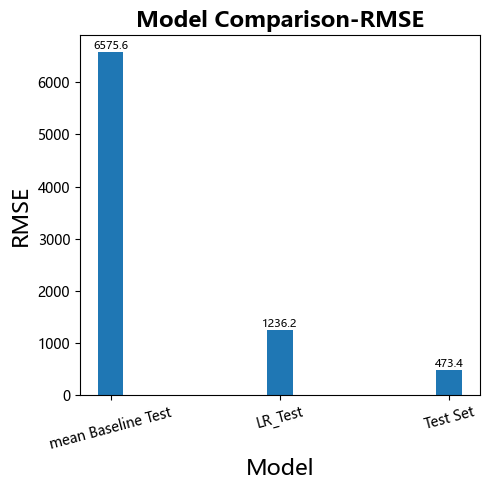

In [57]:
# 13. RMSE对比图

plt.figure(figsize = (5,5))

bars = plt.bar(result_df_test["Dataset"],
               result_df_test["RMSE"],
              width = 0.15
              )
plt.title("Model Comparison-RMSE",fontsize = 16, fontweight = "bold")
plt.xlabel("Model",fontsize = 16)
plt.ylabel("RMSE",fontsize = 16)
plt.xticks(rotation = 15,fontsize=10)
plt.yticks(fontsize=10)

# 给每个柱子顶部添加数值
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha = "center",
        va = "bottom",
        fontsize = 8
    )
    

plt.tight_layout()
plt.savefig("E:/project/1/results/figures/Model_Comparsion_RMSE-test.png",dpi=300)
plt.show()

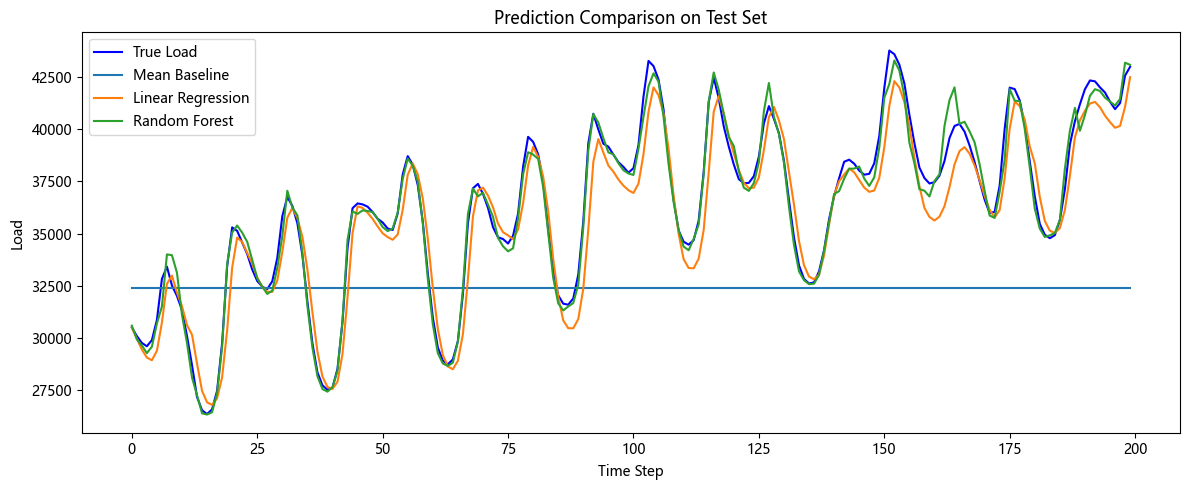

In [56]:
# 14. 预测曲线对比图

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="True Load", color="blue")
plt.plot(y_test_pred_mean[:200], label="Mean Baseline")
plt.plot(y_test__pred_lr[:200], label="Linear Regression")
plt.plot(y_test_pred [:200], label="Random Forest")
plt.title("Prediction Comparison on Test Set")
plt.xlabel("Time Step")
plt.ylabel("Load")
plt.legend()
plt.tight_layout()
plt.savefig("E:/project/1/results/figures/Baseline_lr_rf_prediction_Comparsion-test.png",dpi=300)
plt.show()

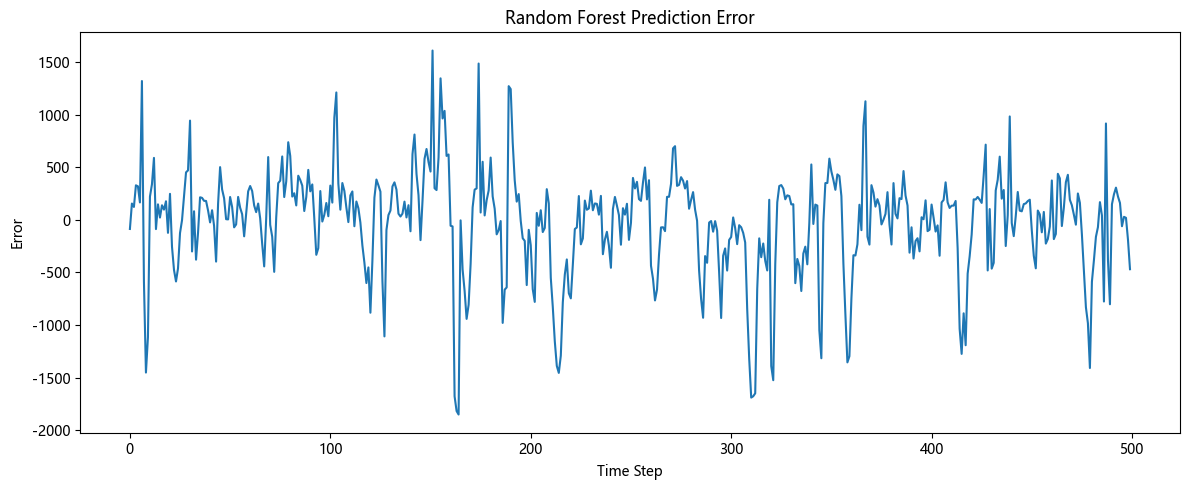

In [61]:
# 15. 误差曲线/残差图

error_rf = y_test.values - y_test_pred

plt.figure(figsize=(12, 5))
plt.plot(error_rf[:500])
plt.title("Random Forest Prediction Error")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


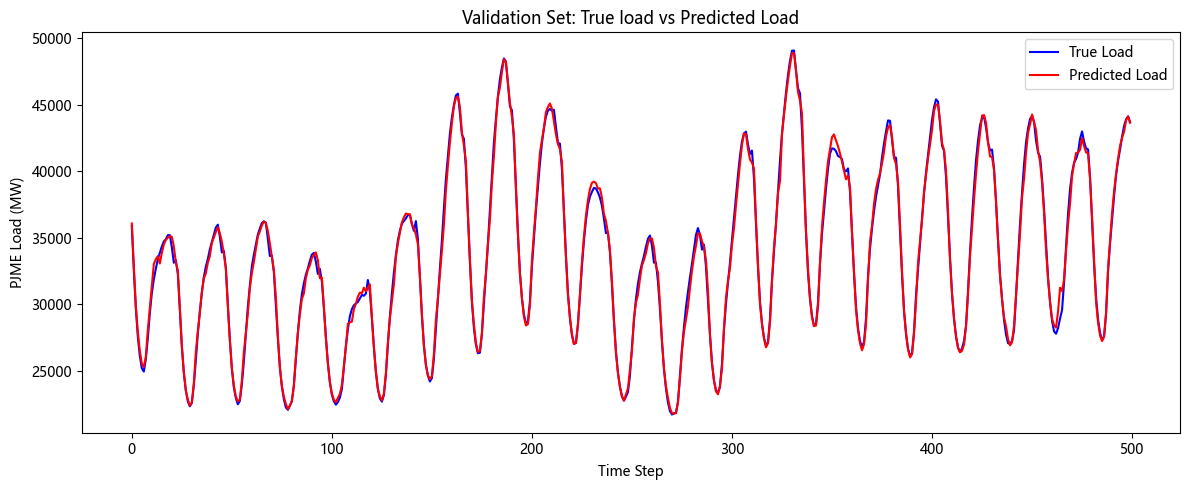

In [8]:
# 8.验证集预测曲线
plt.figure(figsize=(12,5))
plt.plot(y_val.values[:500], label="True Load", color="blue")
plt.plot(y_val_pred[:500], label="Predicted Load", color="red")
plt.xlabel("Time Step")
plt.ylabel("PJME Load (MW)")
plt.title("Validation Set: True load vs Predicted Load")
plt.legend()
plt.tight_layout()
plt.savefig("E:/project/1/results/figures/rf_validation_prediction_curve.png",dpi=300)
plt.show()

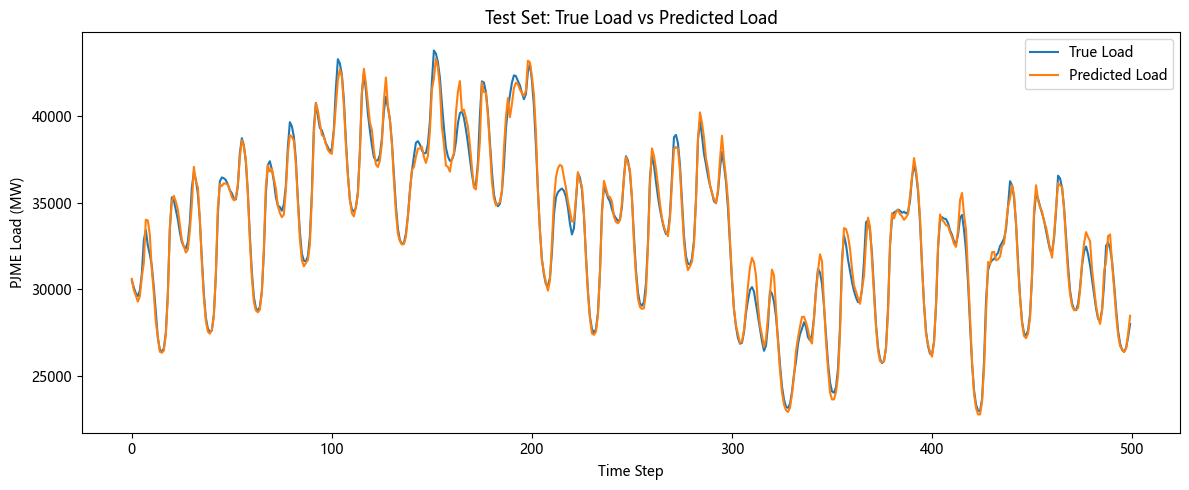

In [9]:
# 9. 测试集预测曲线
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:500], label="True Load")
plt.plot(y_test_pred[:500], label="Predicted Load")
plt.xlabel("Time Step")
plt.ylabel("PJME Load (MW)")
plt.title("Test Set: True Load vs Predicted Load")
plt.legend()
plt.tight_layout()
plt.savefig("E:/project/1/results/figures/rf_test_prediction_curve.png", dpi=300)
plt.show()